In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")


All imports successful


In [2]:
import pandas as pd

# Pull nflverse combine data directly
url = "https://github.com/nflverse/nflverse-data/releases/download/combine/combine.csv"
combine = pd.read_csv(url)

print(combine.shape)
print(combine.head())
print(combine.columns.tolist())

(8968, 18)
   season  draft_year          draft_team  draft_round  draft_ovr    pfr_id  \
0    2000      2000.0       New York Jets          1.0       13.0  AbraJo00   
1    2000      2000.0    Seattle Seahawks          1.0       19.0  AlexSh00   
2    2000      2000.0  Kansas City Chiefs          6.0      188.0  AlfoDa20   
3    2000         NaN                 NaN          NaN        NaN       NaN   
4    2000      2000.0   Carolina Panthers          1.0       23.0  AndeRa21   

              cfb_id       player_name  pos          school   ht     wt  \
0                NaN      John Abraham  OLB  South Carolina  6-4  252.0   
1  shaun-alexander-1   Shaun Alexander   RB         Alabama  6-0  218.0   
2                NaN    Darnell Alford   OT     Boston Col.  6-4  334.0   
3                NaN      Kyle Allamon   TE      Texas Tech  6-2  253.0   
4                NaN  Rashard Anderson   CB   Jackson State  6-2  206.0   

   forty  bench  vertical  broad_jump  cone  shuttle  
0   4.55

In [3]:
# Pull career stats for games started (our primary outcome variable)
url_stats = "https://github.com/nflverse/nflverse-data/releases/download/player_stats/player_stats.csv"
stats = pd.read_csv(url_stats)

print(stats.shape)
print(stats.columns.tolist())

(134470, 53)
['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'recent_team', 'season', 'week', 'season_type', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr', 'special_teams_tds', 'fantasy_points', 'fantasy_points_ppr']


In [4]:
print(stats.columns.tolist())
print(stats.head(3))

['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'recent_team', 'season', 'week', 'season_type', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr', 'special_teams_tds', 'fantasy_points', 'fantasy_points_ppr']
    player_id player_name    player_display_name position position_group

In [5]:
# Filter to regular season only
stats_reg = stats[stats['season_type'] == 'REG']

# Build career totals by player
career = stats_reg.groupby(['player_id', 'player_display_name', 'position']).agg(
    seasons_played=('season', 'nunique'),
    career_rushing_yards=('rushing_yards', 'sum'),
    career_receiving_yards=('receiving_yards', 'sum'),
    career_passing_yards=('passing_yards', 'sum'),
    career_receptions=('receptions', 'sum'),
    career_carries=('carries', 'sum'),
    career_rush_tds=('rushing_tds', 'sum'),
    career_rec_tds=('receiving_tds', 'sum'),
    career_pass_tds=('passing_tds', 'sum'),
).reset_index()

print(career.shape)
print(career.head())

(4134, 12)
    player_id    player_display_name position  seasons_played  \
0  00-0000003  Abdul-Karim al-Jabbar       RB               2   
1  00-0000007         Rabih Abdullah       RB               5   
2  00-0000017         Donnie Abraham       CB               1   
3  00-0000098           Louie Aguiar        P               1   
4  00-0000104            Troy Aikman       QB               2   

   career_rushing_yards  career_receiving_yards  career_passing_yards  \
0                   441                      84                     0   
1                   172                     115                     0   
2                     0                       0                     0   
3                     0                       0                    13   
4                    23                       0                  4536   

   career_receptions  career_carries  career_rush_tds  career_rec_tds  \
0                 17             143                1               1   
1            

In [6]:
# Aggregate combine to one row per player (some players have duplicate entries)
combine_clean = combine.dropna(subset=['forty']).copy()

# Keep only relevant columns
combine_clean = combine_clean[['player_name', 'pos', 'draft_year', 'draft_round', 
                                'draft_ovr', 'ht', 'wt', 'forty', 'bench', 
                                'vertical', 'broad_jump', 'cone', 'shuttle']].drop_duplicates()

# Rename for clarity
combine_clean = combine_clean.rename(columns={
    'player_name': 'player_display_name',
    'pos': 'position'
})

print(combine_clean.shape)
print(combine_clean.head())
print(f"\nNull counts:\n{combine_clean.isnull().sum()}")

(8039, 13)
  player_display_name position  draft_year  draft_round  draft_ovr   ht  \
0        John Abraham      OLB      2000.0          1.0       13.0  6-4   
1     Shaun Alexander       RB      2000.0          1.0       19.0  6-0   
2      Darnell Alford       OT      2000.0          6.0      188.0  6-4   
3        Kyle Allamon       TE         NaN          NaN        NaN  6-2   
4    Rashard Anderson       CB      2000.0          1.0       23.0  6-2   

      wt  forty  bench  vertical  broad_jump  cone  shuttle  
0  252.0   4.55    NaN       NaN         NaN   NaN      NaN  
1  218.0   4.58    NaN       NaN         NaN   NaN      NaN  
2  334.0   5.56   23.0      25.0        94.0  8.48     4.98  
3  253.0   4.97    NaN      29.0       104.0  7.29     4.49  
4  206.0   4.55    NaN      34.0       123.0  7.18     4.15  

Null counts:
player_display_name       0
position                  0
draft_year             2952
draft_round            2952
draft_ovr              2952
ht          

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Metrics where LOWER is better (speed metrics)
lower_is_better = ['forty', 'cone', 'shuttle']
# Metrics where HIGHER is better
higher_is_better = ['bench', 'vertical', 'broad_jump']

# Work position by position
def build_composite(df):
    df = df.copy()
    scaler = MinMaxScaler(feature_range=(0, 10))
    
    for col in lower_is_better:
        if col in df.columns and df[col].notna().sum() > 10:
            valid = df[col].notna()
            # Invert so lower time = higher score
            df.loc[valid, f'{col}_score'] = 10 - scaler.fit_transform(
                df.loc[valid, col].values.reshape(-1, 1)
            ).flatten()
    
    for col in higher_is_better:
        if col in df.columns and df[col].notna().sum() > 10:
            valid = df[col].notna()
            df.loc[valid, f'{col}_score'] = scaler.fit_transform(
                df.loc[valid, col].values.reshape(-1, 1)
            ).flatten()
    
    # Average available scores into composite
    score_cols = [c for c in df.columns if c.endswith('_score')]
    df['athletic_composite'] = df[score_cols].mean(axis=1)
    
    return df

# Apply by position group
combine_scored = combine_clean.groupby('position', group_keys=False).apply(build_composite)

print(combine_scored[['player_display_name', 'position', 'forty', 'athletic_composite']].head(10))
print(f"\nComposite score range: {combine_scored['athletic_composite'].min():.2f} to {combine_scored['athletic_composite'].max():.2f}")

   player_display_name position  forty  athletic_composite
0         John Abraham      OLB   4.55            7.536232
1      Shaun Alexander       RB   4.58            5.072464
2       Darnell Alford       OT   5.56            3.432054
3         Kyle Allamon       TE   4.97            3.437368
4     Rashard Anderson       CB   4.55            4.325087
6      LaVar Arrington      OLB   4.53            7.826087
7         Corey Atkins      OLB   4.72            3.067943
9        Reggie Austin       CB   4.44            5.005877
11      Mark Baniewicz       OT   5.34            5.040056
12      Rashidi Barnes        S   4.62            4.001732

Composite score range: 0.00 to 10.00


In [8]:
# Merge combine with career stats
# Using player name and position as join keys
merged = combine_scored.merge(
    career,
    on=['player_display_name', 'position'],
    how='inner'
)

print(f"Merged dataset shape: {merged.shape}")
print(f"Unique players: {merged['player_display_name'].nunique()}")
print(merged[['player_display_name', 'position', 'athletic_composite', 
              'seasons_played', 'career_rushing_yards', 
              'career_receiving_yards']].head(10))

Merged dataset shape: (1789, 30)
Unique players: 1760
  player_display_name position  athletic_composite  seasons_played  \
0     Shaun Alexander       RB            5.072464               9   
1       Anthony Becht       TE            6.648983              11   
2           Tom Brady       QB            2.882404              23   
3        Travis Brown       QB            2.444876               3   
4         Marc Bulger       QB            3.707682               8   
5       Keith Bulluck      OLB            6.270031               1   
6     Plaxico Burress       WR            3.545010              11   
7      Trung Canidate       RB            6.101449               4   
8         Kwame Cavil       WR            5.125495               1   
9        Doug Chapman       RB            6.249576               3   

   career_rushing_yards  career_receiving_yards  
0                  9445                    1520  
1                     0                    1537  
2                  1123  

In [10]:
# Import the required module
from scipy import stats
import pandas as pd

# Define position groups and their relevant outcome variables
position_outcomes = {
    'QB': 'career_passing_yards',
    'RB': 'career_rushing_yards', 
    'WR': 'career_receiving_yards',
    'TE': 'career_receiving_yards',
    'CB': 'seasons_played',
    'S': 'seasons_played',
    'OLB': 'seasons_played',
    'ILB': 'seasons_played',
    'OT': 'seasons_played',
    'OG': 'seasons_played',
    'C': 'seasons_played',
    'DE': 'seasons_played',
    'DT': 'seasons_played',
}

results = []

for pos, outcome in position_outcomes.items():
    subset = merged[merged['position'] == pos].dropna(subset=['athletic_composite', outcome])
    
    if len(subset) < 20:
        continue
    
    # Now stats.pearsonr() will work correctly with the proper import
    r, p = stats.pearsonr(subset['athletic_composite'], subset[outcome])
    
    results.append({
        'position': pos,
        'outcome': outcome,
        'n': len(subset),
        'r': round(r, 3),
        'r_squared': round(r**2, 3),
        'p_value': round(p, 4),
        'significant': p < 0.05
    })

results_df = pd.DataFrame(results).sort_values('r', ascending=False)
print(results_df.to_string(index=False))

position                outcome   n     r  r_squared  p_value  significant
      CB         seasons_played  24 0.487      0.237   0.0159         True
      TE career_receiving_yards 303 0.272      0.074   0.0000         True
      RB   career_rushing_yards 467 0.138      0.019   0.0028         True
      WR career_receiving_yards 676 0.075      0.006   0.0510        False
      QB   career_passing_yards 212 0.026      0.001   0.7043        False


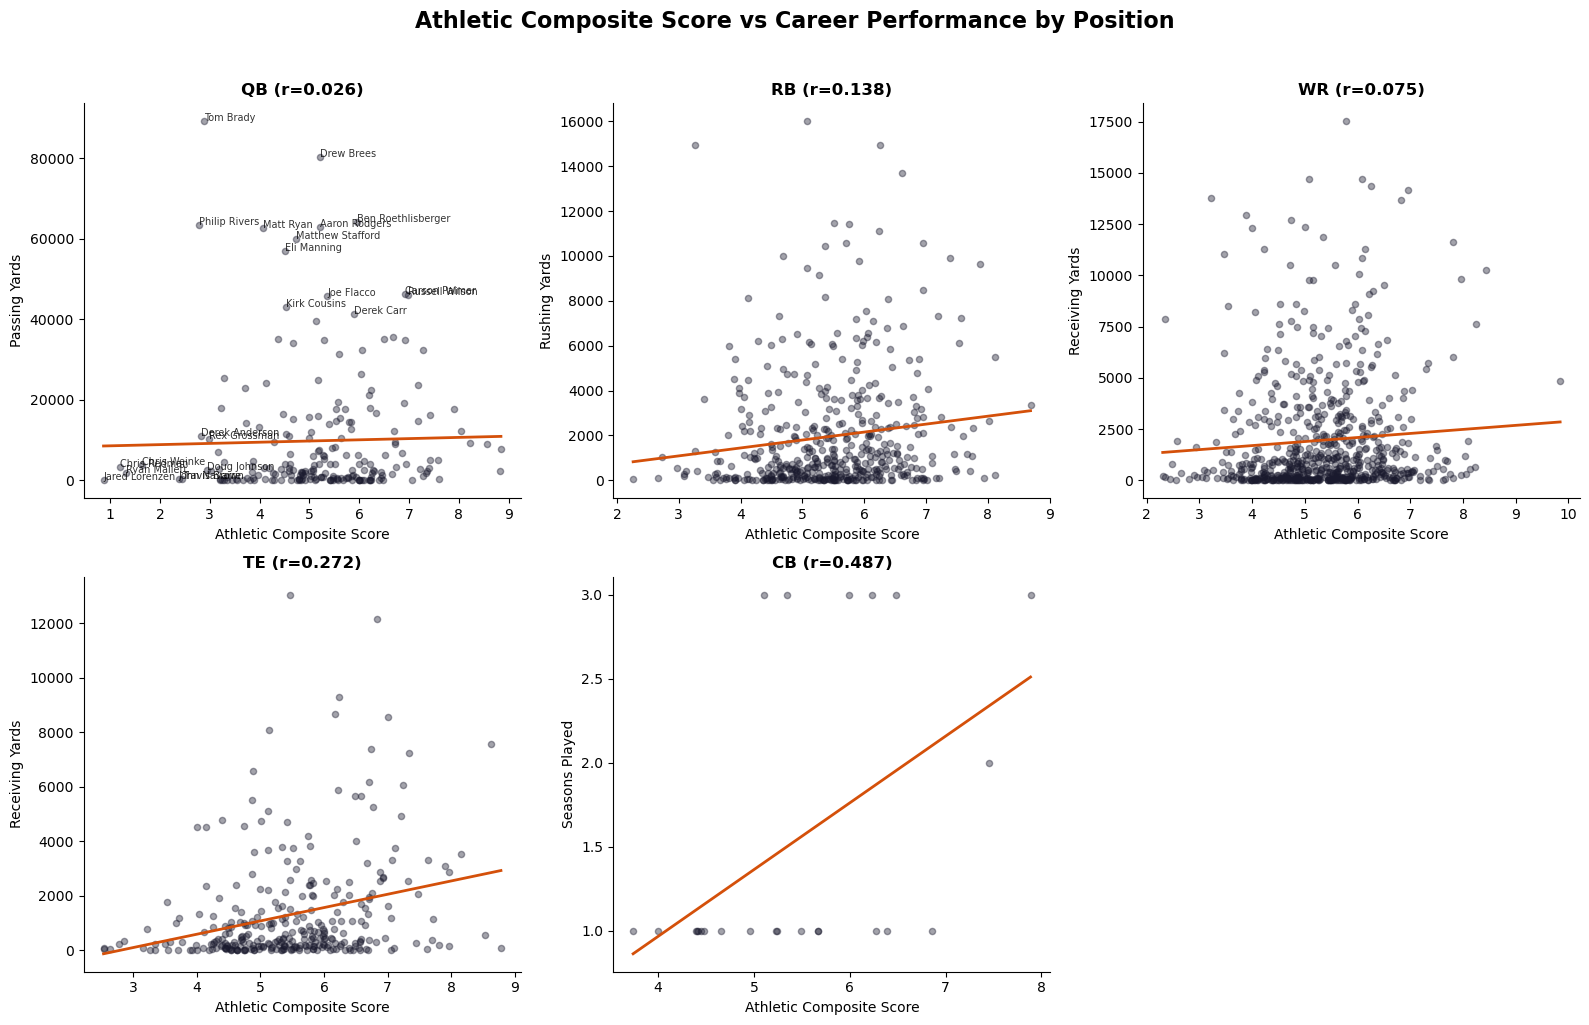

Chart saved


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Athletic Composite Score vs Career Performance by Position', 
             fontsize=16, fontweight='bold', y=1.02)

plot_configs = [
    ('QB', 'career_passing_yards', 'Passing Yards', axes[0,0]),
    ('RB', 'career_rushing_yards', 'Rushing Yards', axes[0,1]),
    ('WR', 'career_receiving_yards', 'Receiving Yards', axes[0,2]),
    ('TE', 'career_receiving_yards', 'Receiving Yards', axes[1,0]),
    ('CB', 'seasons_played', 'Seasons Played', axes[1,1]),
]

for pos, outcome, ylabel, ax in plot_configs:
    subset = merged[merged['position'] == pos].dropna(subset=['athletic_composite', outcome])
    r_val = results_df[results_df['position'] == pos]['r'].values[0]
    
    ax.scatter(subset['athletic_composite'], subset[outcome], 
               alpha=0.4, color='#1a1a2e', s=20)
    
    # Trend line
    z = np.polyfit(subset['athletic_composite'], subset[outcome], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(subset['athletic_composite'].min(), 
                          subset['athletic_composite'].max(), 100)
    ax.plot(x_line, p_line(x_line), color='#D4500A', linewidth=2)
    
    # Label notable outliers for QB
    if pos == 'QB':
        for _, row in subset.iterrows():
            if row['career_passing_yards'] > 40000 or row['athletic_composite'] < 3:
                ax.annotate(row['player_display_name'], 
                           (row['athletic_composite'], row['career_passing_yards']),
                           fontsize=7, alpha=0.8)
    
    ax.set_title(f'{pos} (r={r_val})', fontweight='bold')
    ax.set_xlabel('Athletic Composite Score')
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide the unused 6th subplot
axes[1,2].set_visible(False)

plt.tight_layout()
plt.savefig('athletic_composite_by_position.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")


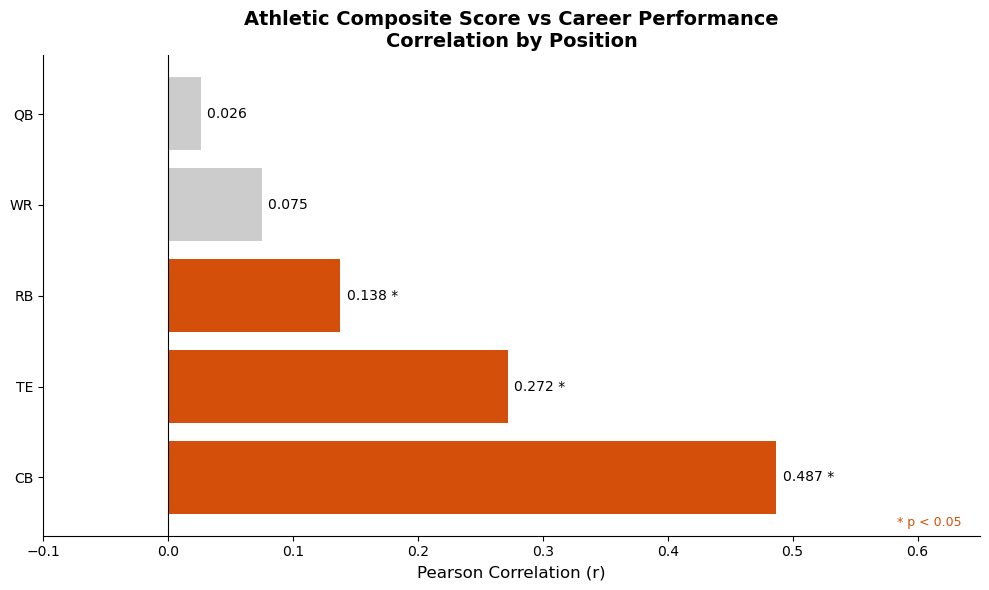

Chart saved


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#D4500A' if sig else '#cccccc' 
          for sig in results_df['significant']]

bars = ax.barh(results_df['position'], results_df['r'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation (r)', fontsize=12)
ax.set_title('Athletic Composite Score vs Career Performance\nCorrelation by Position', 
             fontsize=14, fontweight='bold')

# Add value labels
for bar, r_val, sig in zip(bars, results_df['r'], results_df['significant']):
    label = f'{r_val} {"*" if sig else ""}'
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)

ax.text(0.98, 0.02, '* p < 0.05', transform=ax.transAxes, 
        fontsize=9, ha='right', color='#D4500A')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.1, 0.65)

plt.tight_layout()
plt.savefig('correlation_by_position.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

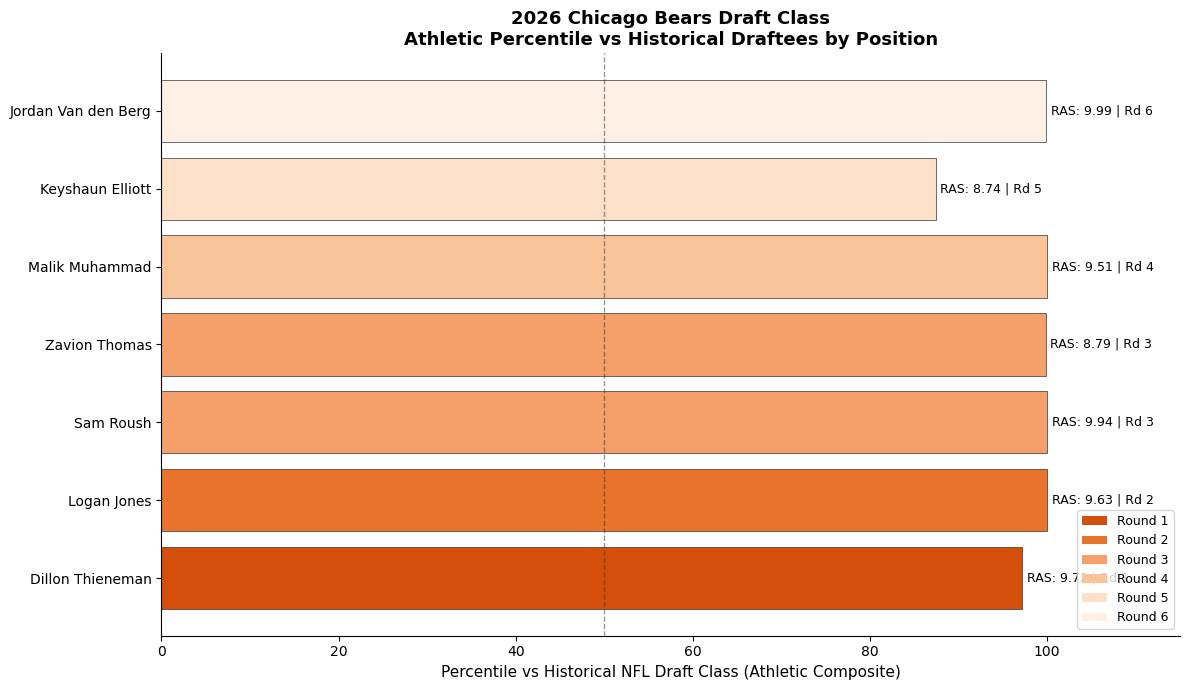

Chart saved


In [13]:
# Bears 2026 draft class RAS scores
bears_class = pd.DataFrame({
    'player': ['Dillon Thieneman', 'Logan Jones', 'Sam Roush', 
               'Zavion Thomas', 'Malik Muhammad', 'Keyshaun Elliott', 
               'Jordan Van den Berg'],
    'position': ['S', 'C', 'TE', 'WR', 'CB', 'ILB', 'DT'],
    'ras_score': [9.72, 9.63, 9.94, 8.79, 9.51, 8.74, 9.99],
    'round': [1, 2, 3, 3, 4, 5, 6]
})

# Get historical percentiles for each position from our composite scores
fig, ax = plt.subplots(figsize=(12, 7))

colors_map = {1: '#D4500A', 2: '#E8732A', 3: '#F5A06A', 
              4: '#FAC49A', 5: '#FDE0C8', 6: '#FEF0E4'}

for _, player in bears_class.iterrows():
    # Map RAS position to our position codes
    pos_map = {'S': 'S', 'C': 'C', 'TE': 'TE', 
               'WR': 'WR', 'CB': 'CB', 'ILB': 'ILB', 'DT': 'DT'}
    
    pos = pos_map.get(player['position'])
    hist = merged[merged['position'] == pos]['athletic_composite']
    
    if len(hist) < 5:
        percentile = player['ras_score'] * 10  # fallback
    else:
        # RAS is already 0-10, convert to percentile vs historical composite
        percentile = (hist < player['ras_score']).mean() * 100
    
    ax.barh(player['player'], percentile, 
            color=colors_map[player['round']], 
            edgecolor='#333333', linewidth=0.5)
    
    ax.text(percentile + 0.5, 
            list(bears_class['player']).index(player['player']),
            f"RAS: {player['ras_score']} | Rd {player['round']}",
            va='center', fontsize=9)

ax.axvline(x=50, color='#333333', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Percentile vs Historical NFL Draft Class (Athletic Composite)', fontsize=11)
ax.set_title('2026 Chicago Bears Draft Class\nAthletic Percentile vs Historical Draftees by Position', 
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Round legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[r], label=f'Round {r}') 
                   for r in sorted(colors_map.keys())]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('bears_2026_draft_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")